# OEDI System 2107 — Electrical Data Audit and Cleaning
- Inputs: electrical CSV and system metadata only. The audit leaves raw inputs unchanged; approved cleaning follows in sections B-F.
- Statistics cover the full file; subsets are labeled.
- Run from the repository root or `notebooks/` with pandas and NumPy. SVG plots need no plotting package.
- Narrow inverter reads bound memory; exact quantiles use every row. Runtime depends on disk speed. Original column names are retained.
- CSV missingness uses pandas' default NA tokens. Nonnumeric values and infinities are counted separately; source values are untouched.

## A. Raw electrical-data audit

In [1]:
from pathlib import Path
import csv, json, re, hashlib, html, platform
from collections import Counter
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
try:
    from IPython.display import display, SVG
except ImportError:
    def display(obj):
        print(obj.to_string() if isinstance(obj, (pd.DataFrame, pd.Series)) else obj)
    def SVG(data):
        return data

ROOT = Path.cwd()
if not (ROOT / 'data/2107/raw/2107_electrical_data.csv').is_file():
    ROOT = ROOT.parent
CSV = ROOT / 'data/2107/raw/2107_electrical_data.csv'
META = ROOT / 'data/2107/raw/2107_system_metadata.json'
assert CSV.is_file() and META.is_file(), 'Run from repository root or notebooks/'
CHUNK = 25000
KINDS = ['dc_current', 'dc_voltage', 'ac_current', 'ac_voltage', 'ac_power']
metadata = json.loads(META.read_text(encoding='utf-8'))
print('Python', platform.python_version(), 'pandas', pd.__version__, 'NumPy', np.__version__)
print('Input:', CSV.relative_to(ROOT), 'bytes:', CSV.stat().st_size,
      'MiB:', round(CSV.stat().st_size / 2**20, 2))

def sha256(path):
    h = hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda: f.read(2**20), b''):
            h.update(block)
    return h.hexdigest()
input_hashes = {str(p.relative_to(ROOT)): sha256(p) for p in (CSV, META)}

Python 3.11.9 pandas 3.0.6 NumPy 2.4.6
Input: data\2107\raw\2107_electrical_data.csv bytes: 438569900 MiB: 418.25


### 1. File and schema
Stream all records to count rows and check widths, empty records, and duplicate parsed-field rows. SHA-256 fingerprints have negligible collision risk. Different numeric spellings remain distinct; timestamp duplicates are checked separately. No wide numeric frame is retained.

In [2]:
row_hashes = set()
exact_duplicate_rows = 0
bad_widths = []
empty_records = 0
with CSV.open(newline='', encoding='utf-8-sig') as f:
    reader = csv.reader(f)
    header = next(reader)
    nrows = 0
    for row in reader:
        nrows += 1
        if not row:
            empty_records += 1
        if len(row) != len(header):
            bad_widths.append((nrows, len(row)))
        digest = hashlib.sha256(json.dumps(row, separators=(',', ':')).encode()).digest()
        exact_duplicate_rows += digest in row_hashes
        row_hashes.add(digest)
del row_hashes
print('Data records:', nrows, 'columns:', len(header), 'empty records:', empty_records)
print('Duplicate header names:', {k:v for k,v in Counter(header).items() if v > 1})
print('Wrong-width records:', len(bad_widths), 'first examples:', bad_widths[:10])
print('Exact duplicate parsed-field rows beyond first occurrence:', exact_duplicate_rows)
assert not bad_widths and not empty_records, 'Structural anomalies require review before numeric audit'
assert len(header) == len(set(header)), 'Duplicate names require positional auditing'
TIMESTAMP = 'measured_on'
assert TIMESTAMP in header
schema_rows = []
for col in header:
    if col == TIMESTAMP:
        continue
    match = re.fullmatch(r'inv_(\d{2})_(dc_current|dc_voltage|ac_current|ac_voltage|ac_power)_(inv|iinv)_(\d+)', col)
    schema_rows.append(dict(column=col, inverter=int(match[1]) if match else None,
                            measurement=match[2] if match else None,
                            suffix=match[3] if match else None,
                            metric_id=int(match[4]) if match else None,
                            canonical_name=bool(match and match[3] == 'inv')))
schema = pd.DataFrame(schema_rows)
print('Timestamp column:', TIMESTAMP, 'logical inverter IDs:', sorted(schema.inverter.dropna().unique()))
print('Represented inverter count:', schema.inverter.nunique())
display(schema)
print('Malformed/noncanonical names:')
display(schema.loc[~schema.canonical_name])
print('Duplicate logical measurements:')
display(schema.loc[schema.duplicated(['inverter','measurement'], keep=False)])
assert schema.inverter.notna().all(), 'Unrecognized columns require explicit handling'

Data records: 632952 columns: 120 empty records: 0
Duplicate header names: {}
Wrong-width records: 0 first examples: []
Exact duplicate parsed-field rows beyond first occurrence: 0
Timestamp column: measured_on logical inverter IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Represented inverter count: 24
Malformed/noncanonical names:
Duplicate logical measurements:


,column,inverter,measurement,suffix,metric_id,canonical_name
0,inv_01_dc_current_inv_149579,1,dc_current,inv,149579,True
1,inv_01_dc_voltage_inv_149580,1,dc_voltage,inv,149580,True
2,inv_01_ac_current_inv_149581,1,ac_current,inv,149581,True
3,inv_01_ac_voltage_inv_149582,1,ac_voltage,inv,149582,True
4,inv_01_ac_power_inv_149583,1,ac_power,inv,149583,True
5,inv_02_dc_current_inv_149584,2,dc_current,inv,149584,True
6,inv_02_dc_voltage_inv_149585,2,dc_voltage,inv,149585,True
7,inv_02_ac_current_inv_149586,2,ac_current,inv,149586,True
8,inv_02_ac_voltage_inv_149587,2,ac_voltage,inv,149587,True
9,inv_02_ac_power_inv_149588,2,ac_power,inv,149588,True


,column,inverter,measurement,suffix,metric_id,canonical_name
73,inv_15_ac_power_iinv_149653,15,ac_power,iinv,149653,False


,column,inverter,measurement,suffix,metric_id,canonical_name


### 2. Metadata and channels
- Logical CSV IDs, metadata keys, equipment IDs, and metric IDs are separate namespaces.
- Name-suffix equipment matching is tentative; metric `source_id` may not confirm it.
- Units come from metadata. Check the five requested electrical channels; other metadata metrics are out of scope.

In [3]:
metric_records = metadata.get('Metrics', {})
inverter_records = metadata.get('Inverters', {})
meta_electrical = {k:v for k,v in metric_records.items() if v.get('source_type') == 'INVERTER'}
checks = []
for row in schema.to_dict('records'):
    m = metric_records.get(row['column'], {})
    expected_unit = {'dc_current':'A','ac_current':'A','dc_voltage':'V','ac_voltage':'V','ac_power':'kw'}[row['measurement']]
    checks.append({**row, 'metadata_present':bool(m), 'metadata_metric_id':m.get('metric_id'),
                   'metric_id_matches':m.get('metric_id') == row['metric_id'],
                   'sensor_name':m.get('sensor_name'), 'units':m.get('units'),
                   'raw_units':m.get('raw_units'), 'source_id':m.get('source_id'),
                   'units_match_expected':str(m.get('units')).lower() == expected_unit.lower(),
                   'scale':m.get('calc_scale'), 'offset':m.get('calc_offset')})
channel_metadata = pd.DataFrame(checks)
display(channel_metadata)
missing_from_csv = sorted(set(meta_electrical) - set(header))
print('Metadata electrical channels absent from CSV:', missing_from_csv)
print('CSV measurements absent from metadata:', sorted(set(schema.column) - set(metric_records)))
print('ID/unit mismatches:')
display(channel_metadata.loc[~channel_metadata.metric_id_matches | ~channel_metadata.units_match_expected])
availability = pd.crosstab(schema.inverter, schema.measurement).reindex(index=range(1,25), columns=KINDS, fill_value=0)
print('Availability: 0 absent, 1 present, >1 duplicate logical channel')
display(availability)
equipment = []
for key, m in inverter_records.items():
    suffix = re.search(r'(\d+)$', m.get('name',''))
    equipment.append(dict(metadata_key=key, equipment_id=m.get('inverter_id'), name=m.get('name'),
                          tentative_logical_id=int(suffix[1]) if suffix else None))
display(pd.DataFrame(equipment))
print('Metadata inverter count:', len(inverter_records))
print('Timezone:', metadata['System'].get('timezone_code'), metadata['System'].get('comments'))
print('System-level coverage/channel notes (not necessarily electrical-only):',
      {k:metadata['System'].get(k) for k in ['first_timestamp','last_timestamp','data_time_resolution','number_data_channels']})

Metadata electrical channels absent from CSV: ['inv_05_dc_voltage_inv_149600']
CSV measurements absent from metadata: []
ID/unit mismatches:
Availability: 0 absent, 1 present, >1 duplicate logical channel
Metadata inverter count: 24
Timezone: PST8PDT Actual timezone is US/Pacific but needed to use special PST8PDT. System is a participant in the DOE Solar Data Prize 2023
System-level coverage/channel notes (not necessarily electrical-only): {'first_timestamp': '2018-12-15 00:15:00', 'last_timestamp': '2023-11-15 12:21:50', 'data_time_resolution': '5-15 min', 'number_data_channels': 125}


,column,inverter,measurement,suffix,metric_id,canonical_name,metadata_present,metadata_metric_id,metric_id_matches,sensor_name,units,raw_units,source_id,units_match_expected,scale,offset
0,inv_01_dc_current_inv_149579,1,dc_current,inv,149579,True,True,149579,True,inv_01_dc_current (A),A,A,None,True,1.0,0.0
1,inv_01_dc_voltage_inv_149580,1,dc_voltage,inv,149580,True,True,149580,True,inv_01_dc_voltage (V),V,V,None,True,1.0,0.0
2,inv_01_ac_current_inv_149581,1,ac_current,inv,149581,True,True,149581,True,inv_01_ac_current (A),A,A,None,True,1.0,0.0
3,inv_01_ac_voltage_inv_149582,1,ac_voltage,inv,149582,True,True,149582,True,inv_01_ac_voltage (V),V,V,None,True,1.0,0.0
4,inv_01_ac_power_inv_149583,1,ac_power,inv,149583,True,True,149583,True,inv_01_ac_power (kW),kw,kw,None,True,1.0,0.0
5,inv_02_dc_current_inv_149584,2,dc_current,inv,149584,True,True,149584,True,inv_02_dc_current (A),A,A,None,True,1.0,0.0
6,inv_02_dc_voltage_inv_149585,2,dc_voltage,inv,149585,True,True,149585,True,inv_02_dc_voltage (V),V,V,None,True,1.0,0.0
7,inv_02_ac_current_inv_149586,2,ac_current,inv,149586,True,True,149586,True,inv_02_ac_current (A),A,A,None,True,1.0,0.0
8,inv_02_ac_voltage_inv_149587,2,ac_voltage,inv,149587,True,True,149587,True,inv_02_ac_voltage (V),V,V,None,True,1.0,0.0
9,inv_02_ac_power_inv_149588,2,ac_power,inv,149588,True,True,149588,True,inv_02_ac_power (kW),kw,kw,None,True,1.0,0.0


,column,inverter,measurement,suffix,metric_id,canonical_name,metadata_present,metadata_metric_id,metric_id_matches,sensor_name,units,raw_units,source_id,units_match_expected,scale,offset


measurement,dc_current,dc_voltage,ac_current,ac_voltage,ac_power
inverter,,,,,
1,1,1,1,1,1
2,1,1,1,1,1
3,1,1,1,1,1
4,1,1,1,1,1
5,1,0,1,1,1
6,1,1,1,1,1
7,1,1,1,1,1
8,1,1,1,1,1
9,1,1,1,1,1


,metadata_key,equipment_id,name,tentative_logical_id
0,Inverter 0,29943,inv_fss_1,1
1,Inverter 1,29944,inv_fss_2,2
2,Inverter 2,29945,inv_fss_3,3
3,Inverter 3,29946,inv_fss_4,4
4,Inverter 4,29947,inv_fss_5,5
5,Inverter 5,29948,inv_fss_6,6
6,Inverter 6,29949,inv_fss_7,7
7,Inverter 7,29950,inv_fss_8,8
8,Inverter 8,29951,inv_fss_9,9
9,Inverter 9,29952,inv_fss_10,10


### 3. Timestamps and DST
- Preserve raw strings; parse a separate timezone-naive series with a strict format.
- Intervals follow file order. Modal-cadence gaps are candidates, not inferred measurements.
- Inspect DST days without assigning offsets or resolving ambiguity.
- For years since 2007, Pacific transitions follow the second Sunday in March and first Sunday in November.

In [4]:
raw_time = pd.read_csv(CSV, usecols=[TIMESTAMP], dtype='str', keep_default_na=False)[TIMESTAMP]
assert len(raw_time) == nrows
parsed = pd.to_datetime(raw_time, format='%Y-%m-%d %H:%M:%S', errors='coerce')
print('First/last raw records:', raw_time.iloc[0], raw_time.iloc[-1])
print('Parsed min/max:', parsed.min(), parsed.max(), 'parse failures:', parsed.isna().sum())
display(pd.DataFrame({'row':np.flatnonzero(parsed.isna()), 'raw':raw_time[parsed.isna()].to_numpy()}))
print('Nondecreasing:', parsed.is_monotonic_increasing, 'strictly increasing:', bool((parsed.diff().iloc[1:] > pd.Timedelta(0)).all()))
print('Raw duplicate occurrences beyond first:', raw_time.duplicated().sum(),
      'parsed duplicate occurrences beyond first:', parsed.dropna().duplicated().sum())
display(pd.DataFrame({'raw':raw_time, 'parsed':parsed}).loc[raw_time.duplicated(keep=False)].head(30))
seconds = parsed.diff().dt.total_seconds()
interval_counts = seconds.value_counts().sort_index()
display(interval_counts.rename('count').to_frame())
cadence = float(seconds[seconds > 0].mode().iloc[0])
print('Modal positive cadence, seconds:', cadence)
irregular = pd.DataFrame({'row':np.arange(nrows), 'previous':raw_time.shift(), 'current':raw_time,
                          'delta_seconds':seconds})
irregular = irregular.loc[seconds.notna() & (seconds != cadence)]
print('Irregular intervals:', len(irregular), 'negative:', (seconds < 0).sum(), 'zero:', (seconds == 0).sum())
display(irregular.head(25))
gaps = irregular.loc[irregular.delta_seconds > cadence].copy()
gaps['candidate_absent_slots'] = np.maximum(np.ceil(gaps.delta_seconds / cadence).astype(int)-1, 0)
gaps['on_cadence_grid'] = np.isclose(gaps.delta_seconds % cadence, 0)
print('Candidate gap periods:', len(gaps), 'candidate absent slots:', gaps.candidate_absent_slots.sum())
display(gaps.sort_values('delta_seconds', ascending=False).head(30))
print('Metadata bounds equal CSV first/last:',
      metadata['System'].get('first_timestamp') == raw_time.iloc[0],
      metadata['System'].get('last_timestamp') == raw_time.iloc[-1])
def sunday(year, month, ordinal):
    d = datetime(year, month, 1)
    return d + timedelta(days=(6-d.weekday()) % 7 + 7*(ordinal-1))
dst_rows = []
assert parsed.min().year >= 2007
for year in range(parsed.min().year, parsed.max().year+1):
    for season, date in [('spring', sunday(year,3,2)), ('fall', sunday(year,11,1))]:
        if not parsed.min().normalize() <= date <= parsed.max().normalize():
            continue
        day_mask = (parsed >= date) & (parsed < date + timedelta(days=1))
        hour = 2 if season == 'spring' else 1
        hour_mask = day_mask & (parsed.dt.hour == hour)
        near_mask = (parsed >= date) & (parsed < date + timedelta(hours=4))
        transitions = irregular.loc[near_mask.reindex(irregular.index)]
        dst_rows.append(dict(year=year, season=season, date=str(date.date()), day_rows=int(day_mask.sum()),
                             critical_hour_rows=int(hour_mask.sum()),
                             critical_hour_duplicates=int(raw_time[hour_mask].duplicated().sum()),
                             irregular_intervals=transitions[['previous','current','delta_seconds']].to_dict('records')))
dst_audit = pd.DataFrame(dst_rows)
display(dst_audit)
print('DST interpretation: spring 02:xx absence plus fall 01:xx repeats/backsteps supports Pacific wall-clock DST;')
print('regular 24-hour transition days with both hours present cannot distinguish UTC from fixed-offset time.')
print('Missing fall repeats can reflect deduplication/export behavior; naive strings alone never establish an offset.')

First/last raw records: 2017-11-01 00:00:00 2023-11-07 23:55:00
Parsed min/max: 2017-11-01 00:00:00 2023-11-07 23:55:00 parse failures: 0
Nondecreasing: True strictly increasing: True
Raw duplicate occurrences beyond first: 0 parsed duplicate occurrences beyond first: 0
Modal positive cadence, seconds: 300.0
Irregular intervals: 6 negative: 0 zero: 0
Candidate gap periods: 6 candidate absent slots: 72
Metadata bounds equal CSV first/last: False False
DST interpretation: spring 02:xx absence plus fall 01:xx repeats/backsteps supports Pacific wall-clock DST;
regular 24-hour transition days with both hours present cannot distinguish UTC from fixed-offset time.
Missing fall repeats can reflect deduplication/export behavior; naive strings alone never establish an offset.


,row,raw


,raw,parsed


,count
measured_on,
300.0,632945
3900.0,6


,row,previous,current,delta_seconds
37464,37464,2018-03-11 01:55:00,2018-03-11 03:00:00,3900.0
142284,142284,2019-03-10 01:55:00,2019-03-10 03:00:00,3900.0
247104,247104,2020-03-08 01:55:00,2020-03-08 03:00:00,3900.0
353940,353940,2021-03-14 01:55:00,2021-03-14 03:00:00,3900.0
458760,458760,2022-03-13 01:55:00,2022-03-13 03:00:00,3900.0
563580,563580,2023-03-12 01:55:00,2023-03-12 03:00:00,3900.0


,row,previous,current,delta_seconds,candidate_absent_slots,on_cadence_grid
37464,37464,2018-03-11 01:55:00,2018-03-11 03:00:00,3900.0,12,True
142284,142284,2019-03-10 01:55:00,2019-03-10 03:00:00,3900.0,12,True
247104,247104,2020-03-08 01:55:00,2020-03-08 03:00:00,3900.0,12,True
353940,353940,2021-03-14 01:55:00,2021-03-14 03:00:00,3900.0,12,True
458760,458760,2022-03-13 01:55:00,2022-03-13 03:00:00,3900.0,12,True
563580,563580,2023-03-12 01:55:00,2023-03-12 03:00:00,3900.0,12,True


,year,season,date,day_rows,critical_hour_rows,critical_hour_duplicates,irregular_intervals
0,2017,fall,2017-11-05,288,12,0,[]
1,2018,spring,2018-03-11,276,0,0,"[{'previous': '2018-03-11 01:55:00', 'current': '2018-03-11 03:00:00', 'delta_seconds': 3900.0}]"
2,2018,fall,2018-11-04,288,12,0,[]
3,2019,spring,2019-03-10,276,0,0,"[{'previous': '2019-03-10 01:55:00', 'current': '2019-03-10 03:00:00', 'delta_seconds': 3900.0}]"
4,2019,fall,2019-11-03,288,12,0,[]
5,2020,spring,2020-03-08,276,0,0,"[{'previous': '2020-03-08 01:55:00', 'current': '2020-03-08 03:00:00', 'delta_seconds': 3900.0}]"
6,2020,fall,2020-11-01,288,12,0,[]
7,2021,spring,2021-03-14,276,0,0,"[{'previous': '2021-03-14 01:55:00', 'current': '2021-03-14 03:00:00', 'delta_seconds': 3900.0}]"
8,2021,fall,2021-11-07,288,12,0,[]
9,2022,spring,2022-03-13,276,0,0,"[{'previous': '2022-03-13 01:55:00', 'current': '2022-03-13 03:00:00', 'delta_seconds': 3900.0}]"


### 4. Numerical and missing-data audit
- Read one inverter (at most five columns) at a time. Dtypes reflect every 25,000-row chunk.
- Exact quantiles use all finite values; nonnumeric tokens and infinities are counted separately.
- Missing runs use consecutive file rows, not elapsed time. Gaps/duplicates affect their time interpretation; first/last missing timestamps follow file order.
- Inspect each channel's minimum/maximum relative to its positive p99. A magnitude ratio of at least 100 flags a review candidate, not invalid data or a cleaning rule. Lower ratios remain unclassified. No model limits or equipment ratings are used.

In [5]:
stats_records, missing_records, extremes, dtype_records, outage_records = [], [], [], [], []
for inverter in sorted(schema.inverter.unique()):
    cols = schema.loc[schema.inverter == inverter, 'column'].tolist()
    parts = []
    observed_types = {c:set() for c in cols}
    for chunk in pd.read_csv(CSV, usecols=cols, chunksize=CHUNK):
        for c in cols:
            observed_types[c].add(str(chunk[c].dtype))
        parts.append(chunk)
    frame = pd.concat(parts, ignore_index=True)
    del parts, chunk
    assert len(frame) == nrows
    inverter_missing = frame.isna().all(axis=1).to_numpy()
    outage_records.append(dict(inverter=inverter, available_channels=len(cols),
                               all_available_channels_missing_rows=int(inverter_missing.sum()),
                               all_available_channels_missing_pct=100*inverter_missing.mean()))
    for col in cols:
        info = schema.set_index('column').loc[col]
        raw_values = frame[col]
        dtype_records.append(dict(column=col, chunk_inferred_dtypes=', '.join(sorted(observed_types[col])),
                                  combined_dtype=str(raw_values.dtype)))
        missing = raw_values.isna().to_numpy()
        converted = pd.to_numeric(raw_values, errors='coerce')
        invalid = raw_values.notna() & converted.isna()
        values = converted.to_numpy(dtype=float, na_value=np.nan)
        finite = values[np.isfinite(values)]
        nonfinite_count = int(np.isinf(values).sum())
        quantiles = np.quantile(finite, [0.01,0.05,0.25,0.5,0.75,0.95,0.99,0.999]) if finite.size else [np.nan]*8
        record = dict(column=col, inverter=inverter, measurement=info.measurement,
                      units=metric_records.get(col,{}).get('units'), count=int(np.count_nonzero(~np.isnan(values))),
                      finite_count=len(finite), missing_count=int(missing.sum()),
                      nonnumeric_count=int(invalid.sum()), infinity_count=nonfinite_count,
                      min=float(np.nanmin(values)) if np.any(~np.isnan(values)) else np.nan,
                      max=float(np.nanmax(values)) if np.any(~np.isnan(values)) else np.nan,
                      mean=float(finite.mean()) if finite.size else np.nan,
                      std=float(finite.std(ddof=1)) if finite.size>1 else np.nan,
                      zeros=int((values == 0).sum()), negatives=int((values < 0).sum()),
                      all_null=bool(missing.all()), constant=bool(raw_values.nunique(dropna=True) == 1))
        record.update(dict(zip(['p01','p05','p25','median','p75','p95','p99','p999'], quantiles)))
        stats_records.append(record)
        padded = np.r_[False, missing, False].astype(np.int8)
        starts = np.flatnonzero(np.diff(padded) == 1)
        ends = np.flatnonzero(np.diff(padded) == -1) - 1
        lengths = ends-starts+1
        longest = int(np.argmax(lengths)) if len(lengths) else None
        missing_records.append(dict(column=col, inverter=inverter, measurement=info.measurement,
            missing_count=int(missing.sum()), missing_pct=100*missing.mean(),
            first_missing=raw_time.iloc[starts[0]] if len(starts) else None,
            last_missing=raw_time.iloc[ends[-1]] if len(ends) else None,
            runs=len(starts), isolated_samples=int((lengths==1).sum()),
            block_runs=int((lengths>1).sum()), longest_run_rows=int(lengths.max()) if len(lengths) else 0,
            longest_start=raw_time.iloc[starts[longest]] if longest is not None else None,
            longest_end=raw_time.iloc[ends[longest]] if longest is not None else None,
            trailing_missing_rows=int(lengths[-1]) if len(ends) and ends[-1]==nrows-1 else 0))
        positive = finite[finite > 0]
        reference = float(np.quantile(positive, .99)) if len(positive) else np.nan
        if len(finite):
            for label, position in [('minimum',int(np.nanargmin(values))),('maximum',int(np.nanargmax(values)))]:
                v = values[position]
                ratio = abs(v)/reference if reference>0 else np.nan
                extremes.append(dict(inverter=inverter, measurement=info.measurement, column=col,
                    selection=label, row=position, timestamp=raw_time.iloc[position], value=float(v),
                    positive_p99=reference, magnitude_ratio=ratio,
                    review_note='orders-of-magnitude candidate' if ratio>=100 else 'unclassified observed extreme',
                    neighborhood=[dict(row=j,timestamp=raw_time.iloc[j],value=float(values[j]))
                                  for j in range(max(0,position-2),min(nrows,position+3))]))
    del frame, raw_values, converted, values, finite, positive
    print(f'Completed inverter {inverter:02d}: {len(cols)} channels, all {nrows:,} rows')
stats = pd.DataFrame(stats_records)
missingness = pd.DataFrame(missing_records)
dtypes = pd.DataFrame(dtype_records)
extreme_observations = pd.DataFrame(extremes)
whole_inverter_outages = pd.DataFrame(outage_records)
print('Timestamp raw dtype:', raw_time.dtype, 'parsed diagnostic dtype:', parsed.dtype)
display(dtypes)
print('All-null/constant/nonnumeric/infinite channels:')
display(stats.loc[stats.all_null | stats.constant | (stats.nonnumeric_count>0) | (stats.infinity_count>0)])
print('Full per-channel missingness:')
display(missingness)
print('Per-inverter missingness (available channels only):')
inverter_missingness = missingness.groupby('inverter').agg(channels=('column','size'), missing_cells=('missing_count','sum'),
    worst_channel_missing_pct=('missing_pct','max'), longest_channel_run=('longest_run_rows','max'), trailing_missing_cells=('trailing_missing_rows','sum'))
inverter_missingness['missing_cell_pct'] = 100*inverter_missingness.missing_cells/(inverter_missingness.channels*nrows)
display(inverter_missingness)
display(whole_inverter_outages)

Completed inverter 01: 5 channels, all 632,952 rows
Completed inverter 02: 5 channels, all 632,952 rows
Completed inverter 03: 5 channels, all 632,952 rows
Completed inverter 04: 5 channels, all 632,952 rows
Completed inverter 05: 4 channels, all 632,952 rows
Completed inverter 06: 5 channels, all 632,952 rows
Completed inverter 07: 5 channels, all 632,952 rows
Completed inverter 08: 5 channels, all 632,952 rows
Completed inverter 09: 5 channels, all 632,952 rows
Completed inverter 10: 5 channels, all 632,952 rows
Completed inverter 11: 5 channels, all 632,952 rows
Completed inverter 12: 5 channels, all 632,952 rows
Completed inverter 13: 5 channels, all 632,952 rows
Completed inverter 14: 5 channels, all 632,952 rows
Completed inverter 15: 5 channels, all 632,952 rows
Completed inverter 16: 5 channels, all 632,952 rows
Completed inverter 17: 5 channels, all 632,952 rows
Completed inverter 18: 5 channels, all 632,952 rows
Completed inverter 19: 5 channels, all 632,952 rows
Completed in

,column,chunk_inferred_dtypes,combined_dtype
0,inv_01_dc_current_inv_149579,float64,float64
1,inv_01_dc_voltage_inv_149580,float64,float64
2,inv_01_ac_current_inv_149581,float64,float64
3,inv_01_ac_voltage_inv_149582,float64,float64
4,inv_01_ac_power_inv_149583,float64,float64
5,inv_02_dc_current_inv_149584,float64,float64
6,inv_02_dc_voltage_inv_149585,float64,float64
7,inv_02_ac_current_inv_149586,float64,float64
8,inv_02_ac_voltage_inv_149587,float64,float64
9,inv_02_ac_power_inv_149588,float64,float64


,column,inverter,measurement,units,count,finite_count,missing_count,nonnumeric_count,infinity_count,min,max,mean,std,zeros,negatives,all_null,constant,p01,p05,p25,median,p75,p95,p99,p999


,column,inverter,measurement,missing_count,missing_pct,first_missing,last_missing,runs,isolated_samples,block_runs,longest_run_rows,longest_start,longest_end,trailing_missing_rows
0,inv_01_dc_current_inv_149579,1,dc_current,366,0.057824,2023-11-06 17:30:00,2023-11-07 23:55:00,1,0,1,366,2023-11-06 17:30:00,2023-11-07 23:55:00,366
1,inv_01_dc_voltage_inv_149580,1,dc_voltage,366,0.057824,2023-11-06 17:30:00,2023-11-07 23:55:00,1,0,1,366,2023-11-06 17:30:00,2023-11-07 23:55:00,366
2,inv_01_ac_current_inv_149581,1,ac_current,366,0.057824,2023-11-06 17:30:00,2023-11-07 23:55:00,1,0,1,366,2023-11-06 17:30:00,2023-11-07 23:55:00,366
3,inv_01_ac_voltage_inv_149582,1,ac_voltage,366,0.057824,2023-11-06 17:30:00,2023-11-07 23:55:00,1,0,1,366,2023-11-06 17:30:00,2023-11-07 23:55:00,366
4,inv_01_ac_power_inv_149583,1,ac_power,366,0.057824,2023-11-06 17:30:00,2023-11-07 23:55:00,1,0,1,366,2023-11-06 17:30:00,2023-11-07 23:55:00,366
5,inv_02_dc_current_inv_149584,2,dc_current,366,0.057824,2023-11-06 17:30:00,2023-11-07 23:55:00,1,0,1,366,2023-11-06 17:30:00,2023-11-07 23:55:00,366
6,inv_02_dc_voltage_inv_149585,2,dc_voltage,366,0.057824,2023-11-06 17:30:00,2023-11-07 23:55:00,1,0,1,366,2023-11-06 17:30:00,2023-11-07 23:55:00,366
7,inv_02_ac_current_inv_149586,2,ac_current,366,0.057824,2023-11-06 17:30:00,2023-11-07 23:55:00,1,0,1,366,2023-11-06 17:30:00,2023-11-07 23:55:00,366
8,inv_02_ac_voltage_inv_149587,2,ac_voltage,366,0.057824,2023-11-06 17:30:00,2023-11-07 23:55:00,1,0,1,366,2023-11-06 17:30:00,2023-11-07 23:55:00,366
9,inv_02_ac_power_inv_149588,2,ac_power,366,0.057824,2023-11-06 17:30:00,2023-11-07 23:55:00,1,0,1,366,2023-11-06 17:30:00,2023-11-07 23:55:00,366


,channels,missing_cells,worst_channel_missing_pct,longest_channel_run,trailing_missing_cells,missing_cell_pct
inverter,,,,,,
1,5,1830,0.057824,366,1830,0.057824
2,5,1830,0.057824,366,1830,0.057824
3,5,0,0.000000,0,0,0.000000
4,5,8640,0.273006,1728,8640,0.273006
5,4,6912,0.273006,1728,6912,0.273006
6,5,8640,0.273006,1728,8640,0.273006
7,5,8640,0.273006,1728,8640,0.273006
8,5,8640,0.273006,1728,8640,0.273006
9,5,8640,0.273006,1728,8640,0.273006


,inverter,available_channels,all_available_channels_missing_rows,all_available_channels_missing_pct
0,1,5,366,0.057824
1,2,5,366,0.057824
2,3,5,0,0.000000
3,4,5,1728,0.273006
4,5,4,1728,0.273006
5,6,5,1728,0.273006
6,7,5,1728,0.273006
7,8,5,1728,0.273006
8,9,5,1728,0.273006
9,10,5,1728,0.273006


### 5. Ranges, zeros, and negatives
Zeros and negatives are counted without classifying them as missing/corrupt. Min/max include numeric infinities if present; means/quantiles use separately counted finite values. Absent channels remain absent in the summaries.

In [6]:
for kind in KINDS:
    print(kind, '? complete-file per-channel statistics')
    display(stats.loc[stats.measurement==kind].drop(columns=['measurement']))
print('Zeros and negatives by inverter/channel:')
display(stats[['inverter','measurement','column','count','missing_count','zeros','negatives']])
operating_ranges = stats.pivot(index='inverter', columns='measurement', values=['min','max','p99']).reindex(columns=pd.MultiIndex.from_product([['min','max','p99'],KINDS]))
display(operating_ranges)
print('Every channel minimum/maximum and selected +/-2-row neighborhoods (examples, not complete event census):')
display(extreme_observations.drop(columns='neighborhood'))
review_candidates = extreme_observations.sort_values('magnitude_ratio', ascending=False).head(8)
for event in review_candidates.to_dict('records'):
    print(event['column'], event['selection'], event['review_note'], 'ratio:', event['magnitude_ratio'])
    display(pd.DataFrame(event['neighborhood']))

dc_current ? complete-file per-channel statistics
dc_voltage ? complete-file per-channel statistics
ac_current ? complete-file per-channel statistics
ac_voltage ? complete-file per-channel statistics
ac_power ? complete-file per-channel statistics
Zeros and negatives by inverter/channel:
Every channel minimum/maximum and selected +/-2-row neighborhoods (examples, not complete event census):
inv_04_ac_current_inv_149596 maximum orders-of-magnitude candidate ratio: 2690028194.9479256
inv_07_dc_voltage_inv_149610 maximum orders-of-magnitude candidate ratio: 1804329606.564622
inv_06_dc_current_inv_149604 maximum orders-of-magnitude candidate ratio: 939663699.3076162
inv_07_ac_power_inv_149613 maximum unclassified observed extreme ratio: 3.5140607799312806
inv_04_ac_power_inv_149598 maximum unclassified observed extreme ratio: 3.459652400173466
inv_02_dc_voltage_inv_149585 maximum unclassified observed extreme ratio: 2.1107191554977405
inv_04_dc_voltage_inv_149595 maximum unclassified obser

,column,inverter,units,count,finite_count,missing_count,nonnumeric_count,infinity_count,min,max,mean,std,zeros,negatives,all_null,constant,p01,p05,p25,median,p75,p95,p99,p999
0,inv_01_dc_current_inv_149579,1,A,632586,632586,366,0,0,0.0,5.234800e+01,9.856498,1.534331e+01,332145,0,False,False,0.0,0.0,0.0,0.000,16.02900,43.54300,48.14800,50.384000
5,inv_02_dc_current_inv_149584,2,A,632586,632586,366,0,0,0.0,5.484400e+01,9.228654,1.492804e+01,331589,0,False,False,0.0,0.0,0.0,0.000,13.96600,42.76100,48.01800,50.419000
10,inv_03_dc_current_inv_149589,3,A,632952,632952,0,0,0,0.0,5.581900e+01,9.988669,1.533945e+01,315761,0,False,False,0.0,0.0,0.0,0.012,16.90000,43.39300,48.02849,50.247049
15,inv_04_dc_current_inv_149594,4,A,631224,631224,1728,0,0,0.0,5.446800e+01,9.336884,1.515216e+01,349751,0,False,False,0.0,0.0,0.0,0.000,13.98225,43.33600,47.83400,50.094777
20,inv_05_dc_current_inv_149599,5,A,631224,631224,1728,0,0,0.0,5.356900e+01,9.840238,1.532161e+01,326381,0,False,False,0.0,0.0,0.0,0.000,16.28700,43.34600,47.89677,50.093777
24,inv_06_dc_current_inv_149604,6,A,631224,631224,1728,0,0,0.0,4.560000e+10,72249.514895,5.739487e+07,345419,0,False,False,0.0,0.0,0.0,0.000,12.68700,42.37300,47.36000,49.834000
29,inv_07_dc_current_inv_149609,7,A,631224,631224,1728,0,0,0.0,5.427400e+01,8.898383,1.489173e+01,360618,0,False,False,0.0,0.0,0.0,0.000,12.23300,42.93900,47.58900,49.824777
34,inv_08_dc_current_inv_149614,8,A,631224,631224,1728,0,0,0.0,5.473000e+01,10.144463,1.570329e+01,321055,0,False,False,0.0,0.0,0.0,0.000,17.01800,44.23585,48.42277,50.420554
39,inv_09_dc_current_inv_149619,9,A,631224,631224,1728,0,0,0.0,5.427700e+01,10.387627,1.570882e+01,310861,0,False,False,0.0,0.0,0.0,0.059,18.31525,43.99400,48.19900,50.289108
44,inv_10_dc_current_inv_149624,10,A,631224,631224,1728,0,0,0.0,5.584300e+01,10.280984,1.579063e+01,317792,0,False,False,0.0,0.0,0.0,0.000,17.59600,44.36800,48.55200,50.513777


,column,inverter,units,count,finite_count,missing_count,nonnumeric_count,infinity_count,min,max,mean,std,zeros,negatives,all_null,constant,p01,p05,p25,median,p75,p95,p99,p999
1,inv_01_dc_voltage_inv_149580,1,V,632586,632586,366,0,0,0.0,9.098400e+02,3.192052e+02,3.373174e+02,329923,0,False,False,0.0,0.0,0.0,0.0000,675.26100,729.0210,755.55800,830.052360
6,inv_02_dc_voltage_inv_149585,2,V,632586,632586,366,0,0,0.0,1.750755e+03,3.161316e+02,3.362738e+02,331589,0,False,False,0.0,0.0,0.0,0.0000,672.87300,731.7430,798.41300,860.897055
11,inv_03_dc_voltage_inv_149590,3,V,632952,632952,0,0,0,0.0,9.097400e+02,3.301870e+02,3.347484e+02,315740,0,False,False,0.0,0.0,0.0,292.4890,675.07700,728.7700,760.67682,853.510617
16,inv_04_dc_voltage_inv_149595,4,V,631224,631224,1728,0,0,0.0,1.487769e+03,3.040377e+02,3.336836e+02,338621,0,False,False,0.0,0.0,0.0,0.0000,673.17300,729.0870,755.84200,820.040000
25,inv_06_dc_voltage_inv_149605,6,V,631224,631224,1728,0,0,0.0,9.120950e+02,3.016139e+02,3.348568e+02,345420,0,False,False,0.0,0.0,0.0,0.0000,672.07200,726.6160,749.34600,804.744059
30,inv_07_dc_voltage_inv_149610,7,V,631224,631224,1728,0,0,0.0,1.380000e+12,2.186520e+06,1.736950e+09,351950,0,False,False,0.0,0.0,0.0,0.0000,670.10100,728.0520,752.71900,823.276209
35,inv_08_dc_voltage_inv_149615,8,V,631224,631224,1728,0,0,0.0,9.136480e+02,3.287109e+02,3.370104e+02,318379,0,False,False,0.0,0.0,0.0,0.0000,676.44700,733.5470,797.66077,859.971000
40,inv_09_dc_voltage_inv_149620,9,V,631224,631224,1728,0,0,0.0,9.217140e+02,3.364687e+02,3.365421e+02,310861,0,False,False,0.0,0.0,0.0,365.2200,679.43700,733.5140,763.62500,863.291432
45,inv_10_dc_voltage_inv_149625,10,V,631224,631224,1728,0,0,0.0,9.156350e+02,3.280015e+02,3.324608e+02,314975,0,False,False,0.0,0.0,0.0,290.2670,668.33000,725.3470,781.55809,851.053000
50,inv_11_dc_voltage_inv_149630,11,V,631224,631224,1728,0,0,0.0,9.124620e+02,3.337538e+02,3.355530e+02,310714,0,False,False,0.0,0.0,0.0,295.0360,680.25500,731.9940,756.61100,801.444641


,column,inverter,units,count,finite_count,missing_count,nonnumeric_count,infinity_count,min,max,mean,std,zeros,negatives,all_null,constant,p01,p05,p25,median,p75,p95,p99,p999
2,inv_01_ac_current_inv_149581,1,A,632586,632586,366,0,0,0.0,3.636300e+01,7.454513,1.136736e+01,335279,0,False,False,0.0,0.0,0.0,0.0,12.696,32.467,34.18900,35.150000
7,inv_02_ac_current_inv_149586,2,A,632586,632586,366,0,0,0.0,3.610300e+01,6.988613,1.097351e+01,345670,0,False,False,0.0,0.0,0.0,0.0,11.175,31.482,33.92000,34.878000
12,inv_03_ac_current_inv_149591,3,A,632952,632952,0,0,0,0.0,3.621800e+01,7.551154,1.127007e+01,327520,0,False,False,0.0,0.0,0.0,0.0,13.392,31.928,33.90000,34.948000
17,inv_04_ac_current_inv_149596,4,A,631224,631224,1728,0,0,0.0,9.350000e+10,148132.059127,1.176847e+08,350566,0,False,False,0.0,0.0,0.0,0.0,11.324,32.543,34.32400,35.287000
21,inv_05_ac_current_inv_149601,5,A,631224,631224,1728,0,0,0.0,3.640000e+01,7.499344,1.137541e+01,336310,0,False,False,0.0,0.0,0.0,0.0,12.993,32.395,34.28800,35.139331
26,inv_06_ac_current_inv_149606,6,A,631224,631224,1728,0,0,0.0,3.617100e+01,6.793178,1.097273e+01,357228,0,False,False,0.0,0.0,0.0,0.0,10.155,31.766,34.11400,35.121000
31,inv_07_ac_current_inv_149611,7,A,631224,631224,1728,0,0,0.0,3.592900e+01,6.830158,1.115816e+01,362566,0,False,False,0.0,0.0,0.0,0.0,9.932,32.426,34.15300,35.194000
36,inv_08_ac_current_inv_149616,8,A,631224,631224,1728,0,0,0.0,3.651400e+01,7.720310,1.159076e+01,328994,0,False,False,0.0,0.0,0.0,0.0,13.509,32.835,34.50300,35.312000
41,inv_09_ac_current_inv_149621,9,A,631224,631224,1728,0,0,0.0,3.626400e+01,7.983449,1.173073e+01,320621,0,False,False,0.0,0.0,0.0,0.0,14.678,33.130,34.50531,35.496000
46,inv_10_ac_current_inv_149626,10,A,631224,631224,1728,0,0,0.0,3.653800e+01,7.812005,1.165219e+01,326221,0,False,False,0.0,0.0,0.0,0.0,13.966,32.807,34.62600,35.556000


,column,inverter,units,count,finite_count,missing_count,nonnumeric_count,infinity_count,min,max,mean,std,zeros,negatives,all_null,constant,p01,p05,p25,median,p75,p95,p99,p999
3,inv_01_ac_voltage_inv_149582,1,V,632586,632586,366,0,0,0.0,310.677,136.362110,143.161743,329929,0,False,False,0.0,0.0,0.0,0.000,286.213,294.232,297.480,302.521375
8,inv_02_ac_voltage_inv_149587,2,V,632586,632586,366,0,0,0.0,310.508,135.249976,143.443901,331597,0,False,False,0.0,0.0,0.0,0.000,287.051,294.717,297.796,302.961980
13,inv_03_ac_voltage_inv_149592,3,V,632952,632952,0,0,0,0.0,310.544,145.218504,144.960139,315752,0,False,False,0.0,0.0,0.0,267.740,289.901,297.354,300.656,303.428000
18,inv_04_ac_voltage_inv_149597,4,V,631224,631224,1728,0,0,0.0,347.127,132.865773,143.867354,338629,0,False,False,0.0,0.0,0.0,0.000,288.043,295.835,299.706,303.564000
22,inv_05_ac_voltage_inv_149602,5,V,631224,631224,1728,0,0,0.0,310.036,138.567962,142.926061,325225,0,False,False,0.0,0.0,0.0,0.000,285.753,292.672,296.089,303.041101
27,inv_06_ac_voltage_inv_149607,6,V,631224,631224,1728,0,0,0.0,311.329,130.691349,143.742364,345420,0,False,False,0.0,0.0,0.0,0.000,288.095,295.302,298.702,303.771101
32,inv_07_ac_voltage_inv_149612,7,V,631224,631224,1728,0,0,0.0,311.498,127.442930,143.129792,351950,0,False,False,0.0,0.0,0.0,0.000,287.208,294.857,298.060,302.706324
37,inv_08_ac_voltage_inv_149617,8,V,631224,631224,1728,0,0,0.0,310.508,141.890221,143.204191,318380,0,False,False,0.0,0.0,0.0,0.000,286.344,293.389,296.710,303.093000
42,inv_09_ac_voltage_inv_149622,9,V,631224,631224,1728,0,0,0.0,310.448,146.715587,144.598272,310870,0,False,False,0.0,0.0,0.0,274.893,289.136,296.672,301.554,305.806000
47,inv_10_ac_voltage_inv_149627,10,V,631224,631224,1728,0,0,0.0,310.303,142.448472,142.733681,314977,0,False,False,0.0,0.0,0.0,9.492,285.490,292.107,295.429,302.969000


...

,row,timestamp,value
0,171751,2019-06-20 10:35:00,0.000
1,171752,2019-06-20 10:40:00,0.000
2,171753,2019-06-20 10:45:00,105.341
3,171754,2019-06-20 10:50:00,0.000
4,171755,2019-06-20 10:55:00,27.037


,row,timestamp,value
0,483641,2022-06-07 12:25:00,0.00
1,483642,2022-06-07 12:30:00,0.00
2,483643,2022-06-07 12:35:00,103.71
3,483644,2022-06-07 12:40:00,0.00
4,483645,2022-06-07 12:45:00,0.00


,row,timestamp,value
0,211183,2019-11-04 08:35:00,708.011
1,211184,2019-11-04 08:40:00,703.418
2,211185,2019-11-04 08:45:00,1750.755
3,211186,2019-11-04 08:50:00,698.976
4,211187,2019-11-04 08:55:00,0.000


,row,timestamp,value
0,489409,2022-06-27 13:05:00,596.433
1,489410,2022-06-27 13:10:00,0.000
2,489411,2022-06-27 13:15:00,1487.769
3,489412,2022-06-27 13:20:00,0.000
4,489413,2022-06-27 13:25:00,0.000


,row,timestamp,value
0,38476,2018-03-14 15:20:00,724.095
1,38477,2018-03-14 15:25:00,715.911
2,38478,2018-03-14 15:30:00,912.095
3,38479,2018-03-14 15:35:00,864.313
4,38480,2018-03-14 15:40:00,888.196


### 6. Diagnostic plots
Three SVG plots cover full-file missingness, interval frequencies, and inverter AC-power max/p99. Interval bars use log(1+count); labels give exact counts and hover titles retain values. Selected extreme neighborhoods are tabulated above.

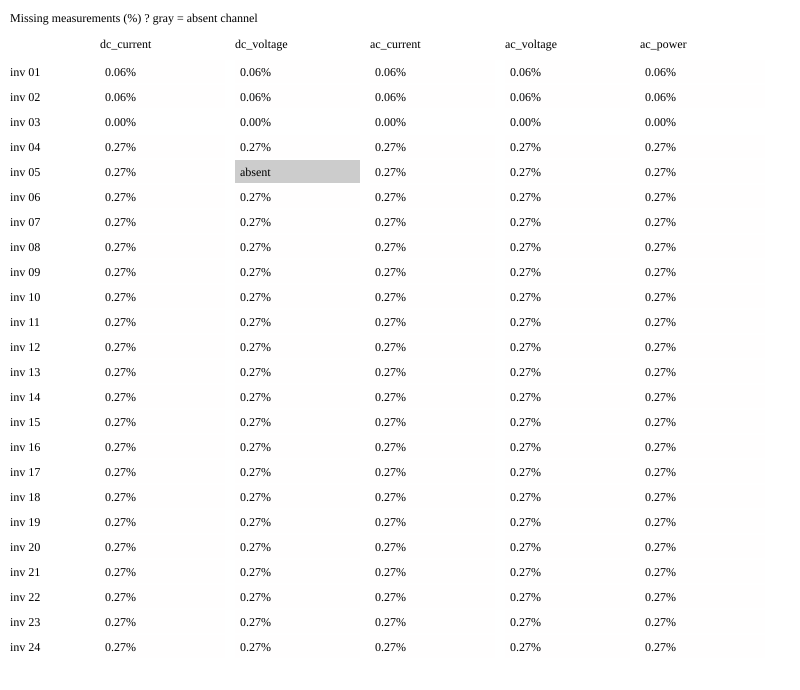

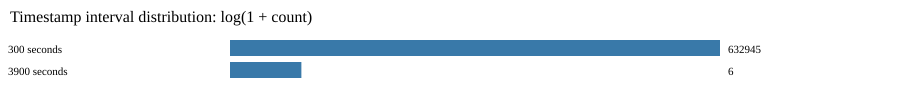

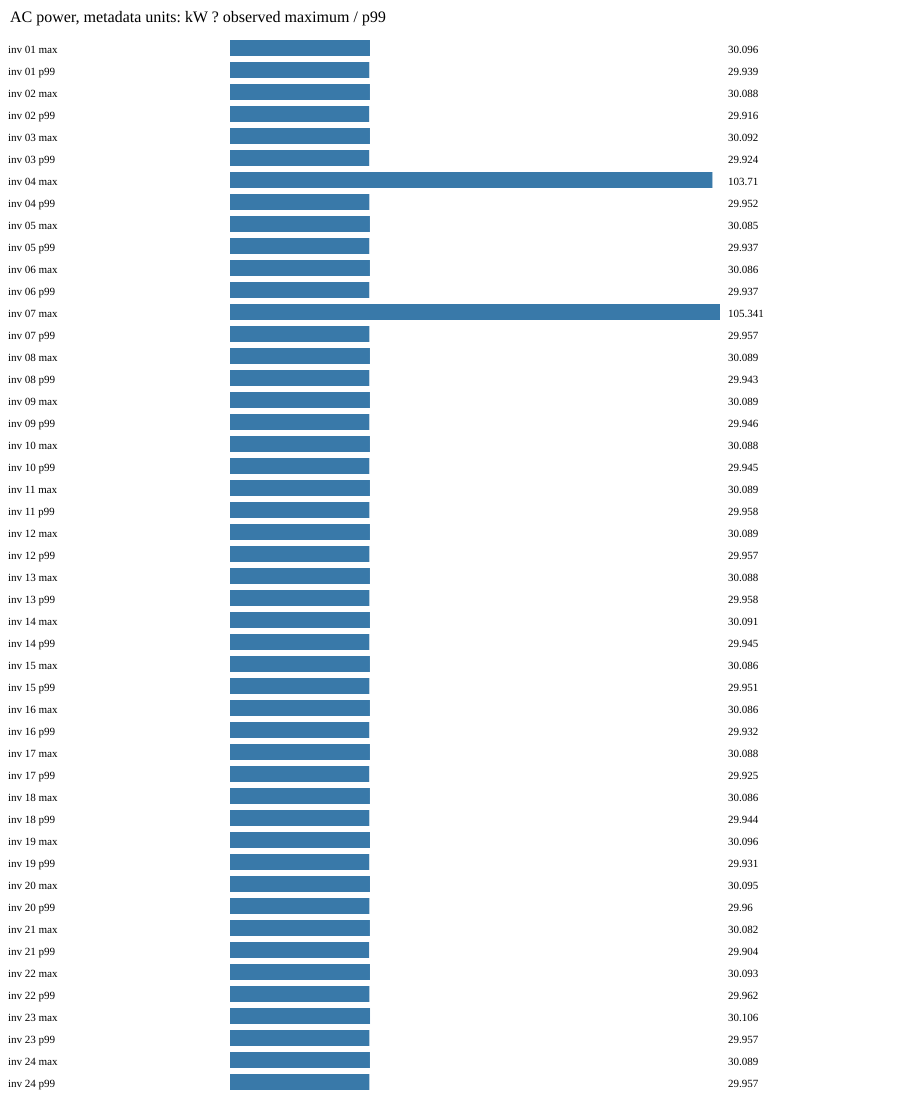

In [7]:
def bars(title, items, log_scale=False):
    width, left, right, rowheight = 900, 230, 180, 22
    height = 55 + len(items)*rowheight
    transformed = [np.log1p(v) if log_scale else v for _,v in items]
    largest = max(transformed, default=1) or 1
    pieces = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
              '<rect width="100%" height="100%" fill="white"/>',
              f'<text x="10" y="22" font-size="16">{html.escape(title)}</text>']
    for i, ((label,value),scaled) in enumerate(zip(items, transformed)):
        y=40+i*rowheight
        barwidth=(width-left-right)*scaled/largest
        pieces.extend([f'<text x="8" y="{y+13}" font-size="11">{html.escape(label)}</text>',
                       f'<rect x="{left}" y="{y}" width="{barwidth}" height="16" fill="#3979a9"><title>{value:g}</title></rect>',
                       f'<text x="{width-right+8}" y="{y+13}" font-size="11">{value:g}</text>'])
    display(SVG(''.join(pieces)+'</svg>'))
# Heatmap distinguishes an absent channel from a present channel with nulls.
heat = missingness.pivot(index='inverter', columns='measurement', values='missing_pct').reindex(index=range(1,25),columns=KINDS)
pieces = ['<svg xmlns="http://www.w3.org/2000/svg" width="800" height="690"><rect width="100%" height="100%" fill="white"/>',
          '<text x="10" y="22">Missing measurements (%) ? gray = absent channel</text>']
for j,k in enumerate(KINDS):
    pieces.append(f'<text x="{100+j*135}" y="48" font-size="12">{k}</text>')
for i,inv in enumerate(heat.index):
    y=60+i*25
    pieces.append(f'<text x="10" y="{y+16}">inv {inv:02d}</text>')
    for j,k in enumerate(KINDS):
        v=heat.loc[inv,k]
        color='#cccccc' if pd.isna(v) else f'rgb(255,{int(255*(1-v/100))},{int(255*(1-v/100))})'
        label='absent' if pd.isna(v) else f'{v:.2f}%'
        pieces.append(f'<rect x="{100+j*135}" y="{y}" width="125" height="23" fill="{color}"/><text x="{105+j*135}" y="{y+16}" font-size="12">{label}</text>')
display(SVG(''.join(pieces)+'</svg>'))
bars('Timestamp interval distribution: log(1 + count)', [(f'{s:g} seconds',int(n)) for s,n in interval_counts.items()], True)
power=stats.loc[stats.measurement=='ac_power'].sort_values('inverter')
bars('AC power, metadata units: kW ? observed maximum / p99',
     [(f'inv {int(r.inverter):02d} {label}',float(r[key])) for _,r in power.iterrows() for label,key in [('max','max'),('p99','p99')] if np.isfinite(r[key])])

### 7. Integrity and evidence
Machine-generated facts support the final summary. SHA-256 checks confirm both permitted inputs stayed unchanged. Other datasets are never opened.

In [8]:
for p in (CSV, META):
    assert sha256(p) == input_hashes[str(p.relative_to(ROOT))], 'Input changed during audit'
print('Input SHA-256 checks passed:', input_hashes)
print('Rows/columns:', nrows,len(header))
print('Absent expected channels:', [(int(i),k) for i in availability.index for k in KINDS if availability.loc[i,k]==0])
print('Noncanonical column names:', schema.loc[~schema.canonical_name,'column'].tolist())
print('Total missing cells:', int(missingness.missing_count.sum()), 'all-null:', int(stats.all_null.sum()), 'constant:',int(stats.constant.sum()))
print('Largest missing percentages:')
display(missingness.sort_values('missing_pct',ascending=False).head(10))
print('Largest magnitude ratios:')
display(extreme_observations.sort_values('magnitude_ratio',ascending=False).head(10).drop(columns='neighborhood'))

Input SHA-256 checks passed: {'data\\2107\\raw\\2107_electrical_data.csv': 'c6d8402ee90ffbeb22cd32e5c371b66dbd0b3e5accaf5f4d83c4988fd91d74d8', 'data\\2107\\raw\\2107_system_metadata.json': '17e4f7f448fcb2bec43f7610b40c1f7f4fc794ccc185e41dcde0514afba73ae5'}
Rows/columns: 632952 120
Absent expected channels: [(5, 'dc_voltage')]
Noncanonical column names: ['inv_15_ac_power_iinv_149653']
Total missing cells: 183372 all-null: 0 constant: 0
Largest missing percentages:
Largest magnitude ratios:


,column,inverter,measurement,missing_count,missing_pct,first_missing,last_missing,runs,isolated_samples,block_runs,longest_run_rows,longest_start,longest_end,trailing_missing_rows
16,inv_04_dc_voltage_inv_149595,4,dc_voltage,1728,0.273006,2023-11-02 00:00:00,2023-11-07 23:55:00,1,0,1,1728,2023-11-02 00:00:00,2023-11-07 23:55:00,1728
17,inv_04_ac_current_inv_149596,4,ac_current,1728,0.273006,2023-11-02 00:00:00,2023-11-07 23:55:00,1,0,1,1728,2023-11-02 00:00:00,2023-11-07 23:55:00,1728
18,inv_04_ac_voltage_inv_149597,4,ac_voltage,1728,0.273006,2023-11-02 00:00:00,2023-11-07 23:55:00,1,0,1,1728,2023-11-02 00:00:00,2023-11-07 23:55:00,1728
19,inv_04_ac_power_inv_149598,4,ac_power,1728,0.273006,2023-11-02 00:00:00,2023-11-07 23:55:00,1,0,1,1728,2023-11-02 00:00:00,2023-11-07 23:55:00,1728
20,inv_05_dc_current_inv_149599,5,dc_current,1728,0.273006,2023-11-02 00:00:00,2023-11-07 23:55:00,1,0,1,1728,2023-11-02 00:00:00,2023-11-07 23:55:00,1728
21,inv_05_ac_current_inv_149601,5,ac_current,1728,0.273006,2023-11-02 00:00:00,2023-11-07 23:55:00,1,0,1,1728,2023-11-02 00:00:00,2023-11-07 23:55:00,1728
22,inv_05_ac_voltage_inv_149602,5,ac_voltage,1728,0.273006,2023-11-02 00:00:00,2023-11-07 23:55:00,1,0,1,1728,2023-11-02 00:00:00,2023-11-07 23:55:00,1728
15,inv_04_dc_current_inv_149594,4,dc_current,1728,0.273006,2023-11-02 00:00:00,2023-11-07 23:55:00,1,0,1,1728,2023-11-02 00:00:00,2023-11-07 23:55:00,1728
37,inv_08_ac_voltage_inv_149617,8,ac_voltage,1728,0.273006,2023-11-02 00:00:00,2023-11-07 23:55:00,1,0,1,1728,2023-11-02 00:00:00,2023-11-07 23:55:00,1728
36,inv_08_ac_current_inv_149616,8,ac_current,1728,0.273006,2023-11-02 00:00:00,2023-11-07 23:55:00,1,0,1,1728,2023-11-02 00:00:00,2023-11-07 23:55:00,1728


,inverter,measurement,column,selection,row,timestamp,value,positive_p99,magnitude_ratio,review_note
35,4,ac_current,inv_04_ac_current_inv_149596,maximum,80516,2018-08-07 14:40:00,9.350000e+10,34.75800,2.690028e+09,orders-of-magnitude candidate
61,7,dc_voltage,inv_07_dc_voltage_inv_149610,maximum,171753,2019-06-20 10:45:00,1.380000e+12,764.82700,1.804330e+09,orders-of-magnitude candidate
49,6,dc_current,inv_06_dc_current_inv_149604,maximum,78804,2018-08-01 16:00:00,4.560000e+10,48.52800,9.396637e+08,orders-of-magnitude candidate
67,7,ac_power,inv_07_ac_power_inv_149613,maximum,171753,2019-06-20 10:45:00,1.053410e+02,29.97700,3.514061e+00,unclassified observed extreme
39,4,ac_power,inv_04_ac_power_inv_149598,maximum,483643,2022-06-07 12:35:00,1.037100e+02,29.97700,3.459652e+00,unclassified observed extreme
13,2,dc_voltage,inv_02_dc_voltage_inv_149585,maximum,211185,2019-11-04 08:45:00,1.750755e+03,829.45900,2.110719e+00,unclassified observed extreme
33,4,dc_voltage,inv_04_dc_voltage_inv_149595,maximum,489411,2022-06-27 13:15:00,1.487769e+03,774.04566,1.922069e+00,unclassified observed extreme
51,6,dc_voltage,inv_06_dc_voltage_inv_149605,maximum,38478,2018-03-14 15:30:00,9.120950e+02,760.80152,1.198861e+00,unclassified observed extreme
141,15,dc_voltage,inv_15_dc_voltage_inv_149650,maximum,38478,2018-03-14 15:30:00,9.160360e+02,765.57880,1.196527e+00,unclassified observed extreme
191,20,dc_voltage,inv_20_dc_voltage_inv_149675,maximum,38478,2018-03-14 15:30:00,9.145330e+02,765.72900,1.194330e+00,unclassified observed extreme


### Electrical Dataset Audit — Findings Requiring Cleaning Decisions

#### A. Observed facts
Executed snapshot; hashes are in section 7. Re-run tables if inputs change.

- **File/schema:** 438,569,900 bytes; 632,952 rows; 120 columns (timestamp + 119 measurements); 24 logical IDs (01?24). No duplicate headers/logical channels/parsed-field rows or wrong-width records.
- **Schema issues:** inverter 05 lacks `inv_05_dc_voltage_inv_149600`, which metadata lists. Inverter 15 uses `inv_15_ac_power_iinv_149653` in CSV and metadata. Other present metric IDs/units match expected electrical types.
- **ID namespaces:** metadata keys `Inverter 0`?`Inverter 23`, names `inv_fss_1`?`inv_fss_24`, equipment IDs 29943?29966. Metric IDs: 149579?149698, with 149600 absent from CSV. Null metric `source_id` leaves name-based equipment associations tentative.
- **Timestamps/DST:** `2017-11-01 00:00:00` to `2023-11-07 23:55:00`; strictly increasing, no parse failures/duplicates; modal cadence 300 seconds. The only six irregular intervals are 3,900-second Pacific spring-forward steps (01:55 to 03:00, 2018?2023). Fall days each have 288 rows and 12 distinct 01:xx records, with no repeats/backsteps. All 72 candidate absent wall-clock slots are spring DST hours, **not established missing physical measurements**. No other cadence gaps. Metadata's system bounds (`2018-12-15 00:15:00` to `2023-11-15 12:21:50`) differ.
- **Missingness:** 183,372 cells, all trailing contiguous blocks. Each available channel of 04?24 lacks 1,728 rows (0.273006%) from `2023-11-02 00:00:00`; 01?02 lack 366 rows (0.057824%) from `2023-11-06 17:30:00`. Blocks end at the file's last row. Inverter 03 has no missing values. No isolated missing samples, all-null/constant columns, nonnumeric tokens, or infinities under the stated CSV NA convention.
- **Enormous measurements:** 04 AC current **9.35e10 A**, `2018-08-07 14:40:00`; 06 DC current **4.56e10 A**, `2018-08-01 16:00:00`; 07 DC voltage **1.38e12 V**, `2019-06-20 10:45:00`. These isolated readings are about 0.94?2.69 billion times positive p99, among much smaller neighbors: strong corruption evidence, cause unresolved. Raw values/statistics retain them.
- **Other high measurements:** 07 AC power 105.341 kW at `2019-06-20 10:45:00`; 04 AC power 103.710 kW at `2022-06-07 12:35:00` (about 3.5 times positive p99). Their neighborhoods warrant review; plausibility remains unresolved and neither is automatically invalid. All channel ranges and zero/negative counts are in section 5.
- **Inverter-specific:** schema issues in 05/15; enormous extrema in 04/06/07; differing outage starts in 01?02 versus 04?24; 03 reports through the final row.
- **Unresolved:** equipment links, export timezone/fall-hour handling, dropout causes, and extreme-value causes/validity need documentation or owner input. CSV units are not self-describing; metadata supports them.

#### B. Tentative interpretations
- Equipment-name associations are unproven by metric source IDs.
- Pacific spring skips plus metadata strongly support local wall-clock DST behavior over a continuous UTC/fixed-offset timeline. Missing fall repeats leave export deduplication/source handling unresolved; no offsets are assigned.
- Values at least 100 times positive p99 are corruption candidates. High values above nominal ratings are not automatically invalid. Flat channels, zeros, negatives, and simultaneous missingness need context.

#### C. Decisions requiring user approval
- Inverter 15 name standardization and representation of 05's absent channel.
- Timezone, ambiguous/nonexistent times, duplicates, and gaps.
- Missing tokens, outages, constant/nonnumeric/nonfinite channels, interpolation, and row/inverter exclusion.
- Treatment of extreme/zero/negative values. No 27.6 kW or approximately 39.44 A cutoff is proposed.

**Audit findings above precede cleaning. Approved rules and outputs follow below.**

## B. Approved cleaning rules
- Preserve every row, timestamp string, zero, and existing missing value; no filling, clipping, resampling, UTC conversion, or rating-based rejection.
- Add inverter 05 DC voltage as entirely missing; correct inverter 15's `iinv` header only.
- Replace exactly three audited corrupt readings with NaN. Keep four suspect extremes unchanged; flag all seven below.
- These approvals cover schema corrections and exact observations only. DST normalization and other decisions remain deferred.

In [9]:
import pyarrow as pa
import pyarrow.parquet as pq

print("pyarrow", pa.__version__)

EXPECTED_ROWS = 632_952
AUDIT_SHA256 = "c6d8402ee90ffbeb22cd32e5c371b66dbd0b3e5accaf5f4d83c4988fd91d74d8"
MISSING_CHANNEL = "inv_05_dc_voltage_inv_149600"
OLD_POWER = "inv_15_ac_power_iinv_149653"
NEW_POWER = "inv_15_ac_power_inv_149653"

# Exact audit observations; row positions are zero-based.
APPROVED_EVENTS = (
    (78_804, "2018-08-01 16:00:00", 6, "dc_current", "inv_06_dc_current_inv_149604", 4.56e10, "qc_corrupt", "Orders-of-magnitude current spike"),
    (80_516, "2018-08-07 14:40:00", 4, "ac_current", "inv_04_ac_current_inv_149596", 9.35e10, "qc_corrupt", "Orders-of-magnitude current spike"),
    (171_753, "2019-06-20 10:45:00", 7, "dc_voltage", "inv_07_dc_voltage_inv_149610", 1.38e12, "qc_corrupt", "Orders-of-magnitude voltage spike"),
    (171_753, "2019-06-20 10:45:00", 7, "ac_power", "inv_07_ac_power_inv_149613", 105.341, "qc_suspect_extreme", "High power; validity unresolved"),
    (211_185, "2019-11-04 08:45:00", 2, "dc_voltage", "inv_02_dc_voltage_inv_149585", 1750.755, "qc_suspect_extreme", "High voltage; validity unresolved"),
    (483_643, "2022-06-07 12:35:00", 4, "ac_power", "inv_04_ac_power_inv_149598", 103.710, "qc_suspect_extreme", "High power; validity unresolved"),
    (489_411, "2022-06-27 13:15:00", 4, "dc_voltage", "inv_04_dc_voltage_inv_149595", 1487.769, "qc_suspect_extreme", "High voltage; validity unresolved"),
)

pyarrow 25.0.1


## C. Cleaning implementation
Process 25,000 rows at a time. Numeric parsing uses float64 round-trip precision; timestamps remain strings. Exact row/timestamp/value checks guard the approved event list. Input chunks are never mutated.

In [10]:
def _clean_columns(raw_columns):
    columns = [NEW_POWER if c == OLD_POWER else c for c in raw_columns]
    if OLD_POWER not in raw_columns or MISSING_CHANNEL in raw_columns:
        raise ValueError("Input does not have the audited electrical schema")
    columns.insert(columns.index("inv_05_dc_current_inv_149599") + 1, MISSING_CHANNEL)
    return columns


def iter_raw_chunks(raw_path, chunk_size=25_000):
    """Read all rows in order, retaining timestamp strings and float64 precision."""
    if chunk_size <= 0:
        raise ValueError("chunk_size must be positive")
    columns = pd.read_csv(raw_path, nrows=0).columns
    dtypes = {c: np.float64 for c in columns if c != TIMESTAMP}
    # The converter preserves timestamp text instead of parsing dates or NA tokens.
    return pd.read_csv(
        raw_path, chunksize=chunk_size, dtype=dtypes,
        converters={TIMESTAMP: str}, float_precision="round_trip",
    )


def apply_approved_changes(raw, row_offset):
    """Return a changed copy and QC records; never mutate the input chunk."""
    clean = raw.rename(columns={OLD_POWER: NEW_POWER}).copy()
    position = clean.columns.get_loc("inv_05_dc_current_inv_149599") + 1
    clean.insert(position, MISSING_CHANNEL, np.nan)
    events = []
    for row, timestamp, inverter, measurement, column, value, flag, reason in APPROVED_EVENTS:
        if not row_offset <= row < row_offset + len(raw):
            continue
        local_row = row - row_offset
        if raw.iloc[local_row][TIMESTAMP] != timestamp or raw.iloc[local_row][column] != value:
            raise ValueError(f"Audited observation differs at row {row}: {column}")
        if flag == "qc_corrupt":
            clean.iat[local_row, clean.columns.get_loc(column)] = np.nan
        events.append(dict(zip(QC_COLUMNS, (timestamp, inverter, measurement, column, value, flag, reason))))
    return clean, events

## D. QC-event generation
The event ledger has seven approved observations: three `qc_corrupt` and four `qc_suspect_extreme`. Writing verifies each against the raw row before recording it.

In [11]:
QC_COLUMNS = ["measured_on", "inverter", "measurement", "raw_column", "raw_value", "flag", "reason"]
QC_SCHEMA = pa.schema([
    ("measured_on", pa.string()), ("inverter", pa.int64()),
    ("measurement", pa.string()), ("raw_column", pa.string()),
    ("raw_value", pa.float64()), ("flag", pa.string()), ("reason", pa.string()),
])
EXPECTED_QC = [dict(zip(QC_COLUMNS, event[1:])) for event in APPROVED_EVENTS]
display(pd.DataFrame(EXPECTED_QC))

,measured_on,inverter,measurement,raw_column,raw_value,flag,reason
0,2018-08-01 16:00:00,6,dc_current,inv_06_dc_current_inv_149604,4.560000e+10,qc_corrupt,Orders-of-magnitude current spike
1,2018-08-07 14:40:00,4,ac_current,inv_04_ac_current_inv_149596,9.350000e+10,qc_corrupt,Orders-of-magnitude current spike
2,2019-06-20 10:45:00,7,dc_voltage,inv_07_dc_voltage_inv_149610,1.380000e+12,qc_corrupt,Orders-of-magnitude voltage spike
3,2019-06-20 10:45:00,7,ac_power,inv_07_ac_power_inv_149613,1.053410e+02,qc_suspect_extreme,High power; validity unresolved
4,2019-11-04 08:45:00,2,dc_voltage,inv_02_dc_voltage_inv_149585,1.750755e+03,qc_suspect_extreme,High voltage; validity unresolved
5,2022-06-07 12:35:00,4,ac_power,inv_04_ac_power_inv_149598,1.037100e+02,qc_suspect_extreme,High power; validity unresolved
6,2022-06-27 13:15:00,4,dc_voltage,inv_04_dc_voltage_inv_149595,1.487769e+03,qc_suspect_extreme,High voltage; validity unresolved


## E. Parquet outputs
Reruns replace only the two derived electrical Parquet files. The audited raw hash must match before writing. No other datasets are opened.

In [12]:
if sha256(CSV) != AUDIT_SHA256:
    raise ValueError("Raw CSV hash differs from the audited input")
PROCESSED = ROOT / "data/2107/processed"
CLEAN_PATH = PROCESSED / "2107_electrical_clean.parquet"
QC_PATH = PROCESSED / "2107_electrical_qc_events.parquet"
clean_columns = _clean_columns(header)
clean_schema = pa.schema([(c, pa.string() if c == TIMESTAMP else pa.float64()) for c in clean_columns])
PROCESSED.mkdir(parents=True, exist_ok=True)
rows_written, written_events = 0, []
with pq.ParquetWriter(CLEAN_PATH, clean_schema, compression="snappy") as writer:
    for raw_chunk in iter_raw_chunks(CSV, CHUNK):
        clean_chunk, chunk_events = apply_approved_changes(raw_chunk, rows_written)
        writer.write_table(pa.Table.from_pandas(clean_chunk, schema=clean_schema, preserve_index=False))
        written_events.extend(chunk_events)
        rows_written += len(raw_chunk)
        del raw_chunk, clean_chunk
if rows_written != EXPECTED_ROWS or written_events != EXPECTED_QC:
    raise ValueError("Unexpected row count or approved events")
pq.write_table(pa.Table.from_pylist(written_events, schema=QC_SCHEMA), QC_PATH, compression="snappy")
print("Rows written:", rows_written)
print("Outputs:", CLEAN_PATH.relative_to(ROOT), QC_PATH.relative_to(ROOT))

Rows written: 632952
Outputs: data\2107\processed\2107_electrical_clean.parquet data\2107\processed\2107_electrical_qc_events.parquet


## F. Validation
Read both Parquet files and compare every measurement with raw data in row order. Allow exactly three approved NaNs; verify schema corrections, timestamp strings, missingness, zeros, suspect values, and raw hashes. The 29-31 kW and >39.44 A counts document preservation; they are not cleaning rules.

In [13]:
def validate_electrical_data(raw_path, clean_path, qc_path, chunk_size=25_000):
    """Compare every output cell with raw data, permitting exactly three NaNs."""
    if sha256(raw_path) != AUDIT_SHA256:
        raise ValueError("Raw CSV hash differs from the audited input")
    raw_columns = pd.read_csv(raw_path, nrows=0).columns.tolist()
    clean_columns = _clean_columns(raw_columns)
    parquet = pq.ParquetFile(clean_path)
    expected_schema = pa.schema([(c, pa.string() if c == TIMESTAMP else pa.float64()) for c in clean_columns])
    if not parquet.schema_arrow.equals(expected_schema, check_metadata=False):
        raise ValueError("Unexpected clean Parquet columns or data types")
    if parquet.metadata.num_rows != EXPECTED_ROWS:
        raise ValueError("Unexpected clean Parquet row count")
    batches = parquet.iter_batches(batch_size=chunk_size)
    offset = changed = missing = zeros = near_30kw = above_39a = 0
    for raw in iter_raw_chunks(raw_path, chunk_size):
        batch = next(batches, None)
        if batch is None or batch.num_rows != len(raw):
            raise ValueError("Raw/Parquet row boundaries differ")
        clean = batch.to_pandas()
        if not np.array_equal(raw[TIMESTAMP].to_numpy(), clean[TIMESTAMP].to_numpy()):
            raise ValueError("Timestamp strings or row order changed")
        if not clean[MISSING_CHANNEL].isna().all():
            raise ValueError("Inverter 05 DC voltage is not entirely missing")
        for column in raw_columns:
            if column == TIMESTAMP:
                continue
            before = raw[column].to_numpy()
            after = clean[NEW_POWER if column == OLD_POWER else column].to_numpy()
            allowed = np.zeros(len(raw), dtype=bool)
            for row, timestamp, _, _, event_column, value, flag, _ in APPROVED_EVENTS:
                if flag == "qc_corrupt" and event_column == column and offset <= row < offset + len(raw):
                    index = row - offset
                    if raw.iloc[index][TIMESTAMP] != timestamp or before[index] != value:
                        raise ValueError("Approved corruption does not match raw observation")
                    allowed[index] = True
            same = (before == after) | (np.isnan(before) & np.isnan(after))
            if not np.array_equal(~same, allowed) or not np.isnan(after[allowed]).all():
                raise ValueError(f"Unapproved measurement change in {column}")
            changed += int(allowed.sum())
            missing += int(np.isnan(before).sum())
            zeros += int((before == 0).sum())
            # These counts document preservation; they are never cleaning conditions.
            if "_ac_power_" in column:
                near_30kw += int(((before >= 29) & (before <= 31)).sum())
            if "_dc_current_" in column:
                above_39a += int(((before > 39.44) & ~allowed).sum())
        offset += len(raw)
    if next(batches, None) is not None or offset != EXPECTED_ROWS or changed != 3:
        raise ValueError("Unexpected row count or corrupt-value change count")
    qc = pq.read_table(qc_path)
    if not qc.schema.equals(QC_SCHEMA, check_metadata=False):
        raise ValueError("Unexpected QC Parquet data types")
    expected_events = EXPECTED_QC
    if qc.to_pylist() != expected_events:
        raise ValueError("QC events differ from the seven approved observations")
    if sha256(raw_path) != AUDIT_SHA256:
        raise ValueError("Raw CSV changed during validation")
    return {
        "rows": offset, "columns": len(clean_columns), "raw_sha256": AUDIT_SHA256,
        "changed_to_nan": changed, "qc_corrupt": 3, "qc_suspect_extreme": 4,
        "preexisting_missing_preserved": missing, "zeros_preserved": zeros,
        "ac_power_29_to_31_kw_preserved": near_30kw,
        "dc_current_above_39_44_a_preserved": above_39a,
        "timestamps_and_order_preserved": True, "all_other_values_preserved": True,
        "parquet_types_and_row_count_verified": True,
    }

validation_report = validate_electrical_data(CSV, CLEAN_PATH, QC_PATH, CHUNK)
for input_path in (CSV, META):
    assert sha256(input_path) == input_hashes[str(input_path.relative_to(ROOT))]
display(pd.Series(validation_report, name="validation"))
print("Raw electrical CSV and metadata hashes unchanged.")

Raw electrical CSV and metadata hashes unchanged.


rows                                                                               632952
columns                                                                               121
raw_sha256                              c6d8402ee90ffbeb22cd32e5c371b66dbd0b3e5accaf5f...
changed_to_nan                                                                          3
qc_corrupt                                                                              3
qc_suspect_extreme                                                                      4
preexisting_missing_preserved                                                      183372
zeros_preserved                                                                  39082717
ac_power_29_to_31_kw_preserved                                                     628664
dc_current_above_39_44_a_preserved                                                1510451
timestamps_and_order_preserved                                                       True
all_other_